In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
weather_df = pd.read_csv("../data/raw/Data Phoenix Park.csv",skiprows=14,na_values=[""])

print("="*100)
print("data loaded")
print("="*100)
print(weather_df.head()) #print first 5 lines 
print(weather_df.dtypes) #print column datatypes before mutation
print(weather_df.shape) #print rows and cols
print("="*100)

#2 Change datatypes
#change date to datetime, turns other columns to numeric, strings that passed get turned to NaN
weather_df["date"] = pd.to_datetime(weather_df["date"], format="%d-%b-%y")
weather_df["maxtp"] = pd.to_numeric(weather_df["maxtp"], errors="coerce")
weather_df["mintp"] = pd.to_numeric(weather_df["mintp"], errors="coerce")
weather_df["rain"] = pd.to_numeric(weather_df["rain"], errors="coerce")

#mean column created for temperature
weather_df['meantp'] = (weather_df['maxtp'] + weather_df['mintp'])/2

#created columns for year, day and month
weather_df['year'] = weather_df['date'].dt.year
weather_df['day_of_year'] = weather_df['date'].dt.day_of_year
# line tells pandas that there are only x amount of options, and that the order matters
weather_df['month'] = pd.Categorical(weather_df['date'].dt.month_name(), categories=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], ordered=True)

print(weather_df.dtypes)
print("="*100)

#3 Make variables for later graphs
#calculate long term daily average/max/min 
# reset index is just used it turns whatever column from an index back into a column in the dataframe after the groupby function
long_term_daily_avg = weather_df.groupby('day_of_year')['meantp'].mean().reset_index()
long_term_daily_max = weather_df.groupby('day_of_year')['maxtp'].mean().reset_index()
long_term_daily_min = weather_df.groupby('day_of_year')['mintp'].mean().reset_index()

# .head(365) is because weather_df['date'].dt.day_of_year defaults to 366 days
#1st and 3rd quartile and 10th and 90th percentile for mean
daily_q1 = weather_df.groupby('day_of_year')['meantp'].quantile(0.25).head(365).values
daily_q3 = weather_df.groupby('day_of_year')['meantp'].quantile(0.75).head(365).values
daily_p90 = weather_df.groupby('day_of_year')['meantp'].quantile(0.9).head(365).values
daily_p10 = weather_df.groupby('day_of_year')['meantp'].quantile(0.1).head(365).values

#1st and 3rd quartile and 10th and 90th percentile for max
max_daily_q1 = weather_df.groupby('day_of_year')['maxtp'].quantile(0.25).head(365).values
max_daily_q3 = weather_df.groupby('day_of_year')['maxtp'].quantile(0.75).head(365).values
max_daily_p90 = weather_df.groupby('day_of_year')['maxtp'].quantile(0.9).head(365).values

#1st and 3rd quartile and 10th and 90th percentile for min
min_daily_q1 = weather_df.groupby('day_of_year')['mintp'].quantile(0.25).head(365).values
min_daily_q3 = weather_df.groupby('day_of_year')['mintp'].quantile(0.75).head(365).values
min_daily_p10 = weather_df.groupby('day_of_year')['mintp'].quantile(0.1).head(365).values

# dataframes for later use in graphs
# filter for monthly rain in mm
monthly_rain_mm = weather_df.groupby('month',observed=False)['rain'].sum().reset_index()
# Filter for 2019
df_2019 = weather_df[weather_df['year'] == 2019]


data loaded
        date  ind maxtp  ind.1 mintp igmin gmin ind.2 rain     cbl    soil
0  16-Aug-03    0  20.1      0   7.5     4          0    0  1013.7  18.565
1  17-Aug-03    0  21.3      0  11.6     0  7.5     0  1.1  1007.5   18.28
2  18-Aug-03    0  20.3      0   8.5     0  4.3     0    0  1008.8  17.825
3  19-Aug-03    0  19.9      0  11.3     0  7.7     0    0  1014.3  18.138
4  20-Aug-03    0  21.5      0  10.8     0  6.9     0    0  1013.6  18.432
date       str
ind      int64
maxtp      str
ind.1    int64
mintp      str
igmin      str
gmin       str
ind.2      str
rain       str
cbl        str
soil       str
dtype: object
(8160, 11)
date           datetime64[us]
ind                     int64
maxtp                 float64
ind.1                   int64
mintp                 float64
igmin                     str
gmin                      str
ind.2                     str
rain                  float64
cbl                       str
soil                      str
meantp            

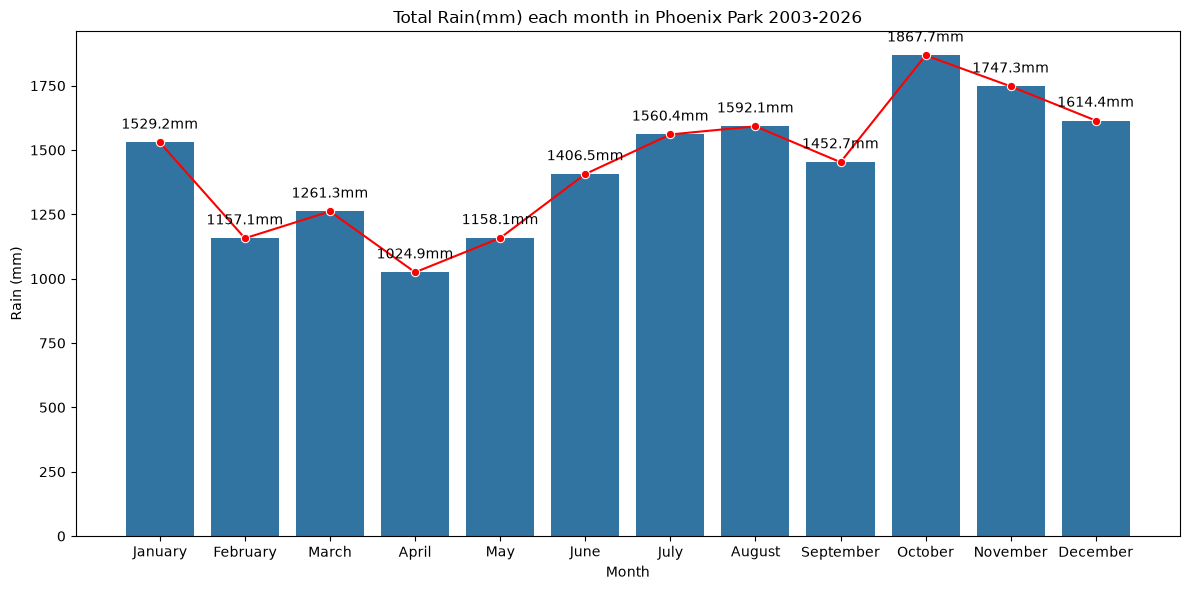

In [23]:
plt.figure(figsize=(12, 6))

# Total rain each month (Bar plot) - Assign directly to 'ax'
ax = sns.barplot(data=monthly_rain_mm, x='month', y='rain')

# Add line across the bars
sns.lineplot(data=monthly_rain_mm, x='month', y='rain', color='red', marker='o', ax=ax)

plt.title("Total Rain(mm) each month in Phoenix Park 2003-2026")
plt.xlabel("Month")
plt.ylabel("Rain (mm)")

# Annotate each bar/point with its value
for idx, row in monthly_rain_mm.iterrows():
    ax.annotate(
        text=f'{row["rain"]}mm',
        xy=(idx, row['rain']),
        xytext=(0, 10),
        textcoords="offset points",
        ha='center'
    )

plt.tight_layout()
plt.savefig("../outputs/images/Total Rain each month in Phoenix Park 2003-2026")
plt.show()

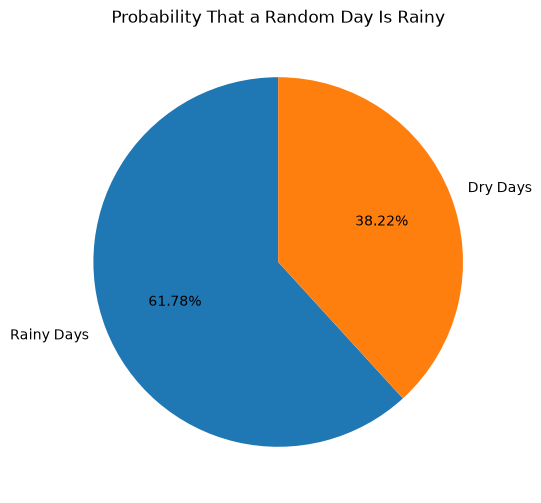

In [17]:
plt.figure(figsize=(6, 6))
# Calculate rainy vs dry days
rainy_days = (weather_df['rain'] > 0).sum()
dry_days = (weather_df['rain'] == 0).sum()

# values and labels
labels = ['Rainy Days', 'Dry Days']
values = [rainy_days, dry_days]

# Plot pie chart
plt.pie(values, labels=labels, autopct='%1.2f%%', startangle=90)
plt.title("Probability That a Random Day Is Rainy")
plt.savefig("../outputs/images/Probability That a Random Day Is Rainy")
plt.show()


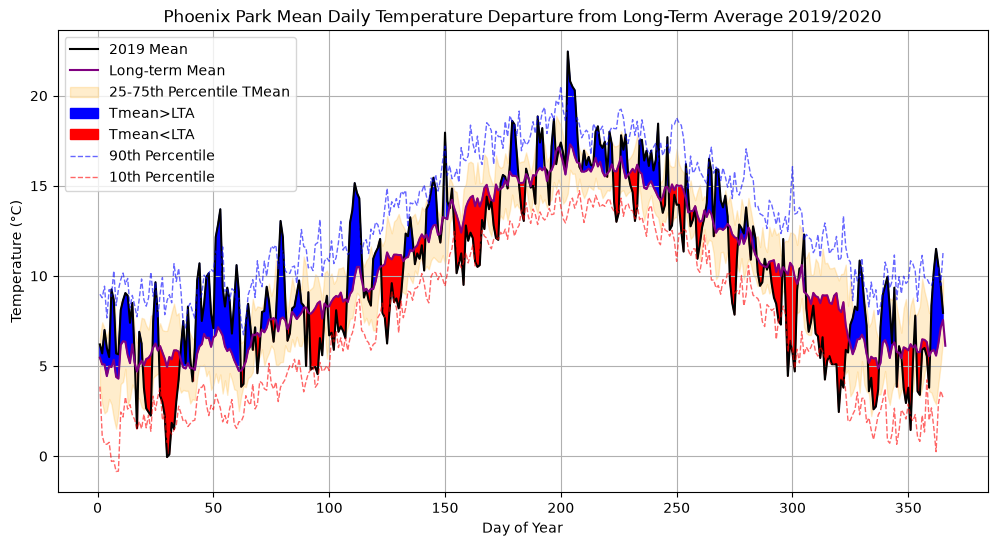

In [18]:
# #2019 vs LTA
plt.figure(figsize=(12, 6))

# Plot 2019
sns.lineplot(data=df_2019, x='day_of_year', y='meantp', color='black',label = '2019 Mean')

# Plot Long-term Mean
sns.lineplot(data=long_term_daily_avg, x='day_of_year', y='meantp', label='Long-term Mean', color='purple')

# Use .head(365) to make sure it matches the length of 2019 because for some reason it default to 366 days 
lta_list = long_term_daily_avg['meantp'].head(365).values

#fill between 1st and 3rd quartiles
plt.fill_between(df_2019['day_of_year'], daily_q1, daily_q3, 
                color='orange', alpha=0.2, label='25-75th Percentile TMean')

#fill between above LTA and 2019 mean
plt.fill_between(df_2019['day_of_year'], df_2019['meantp'], lta_list,where=(df_2019['meantp'] >= lta_list),color='blue',label = "Tmean>LTA")

#fill between under LTA and 2019 Mean
plt.fill_between(df_2019['day_of_year'], df_2019['meantp'], lta_list,where=(df_2019['meantp'] < lta_list),color='red',label = "Tmean<LTA")

# Plot 90th percentile
plt.plot(df_2019['day_of_year'], daily_p90, 
        color='blue', linestyle='--', linewidth=1, alpha=0.6, label='90th Percentile')

# Plot the 10th percentile
plt.plot(df_2019['day_of_year'], daily_p10, 
        color='red', linestyle='--', linewidth=1, alpha=0.6, label='10th Percentile')

#titles, labels
plt.title('Phoenix Park Mean Daily Temperature Departure from Long-Term Average 2019/2020')
plt.xlabel('Day of Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.savefig("../outputs/images/Mean Daily Temperature 2019-2020")
plt.show()


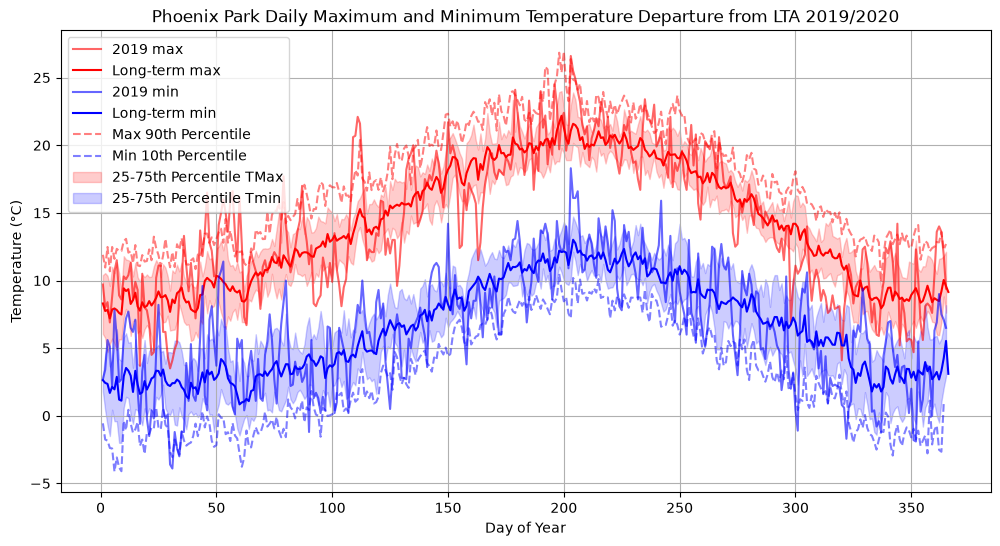

In [19]:
#2019 vs LTA
plt.figure(figsize=(12, 6))

# Plot 2019
sns.lineplot(data=df_2019, x='day_of_year', y='maxtp', color='red',alpha = 0.6,label = '2019 max')
# Plot Long-term max
sns.lineplot(data=long_term_daily_max, x='day_of_year', y='maxtp', label='Long-term max', color='red')

# 2019 Min line
sns.lineplot(data=df_2019, x='day_of_year', y='mintp', color='blue',alpha = 0.6,label = '2019 min')
# Plot Long-term min
sns.lineplot(data=long_term_daily_min, x='day_of_year', y='mintp', label='Long-term min', color='blue')

# Plot max percentiles
plt.plot(df_2019['day_of_year'], max_daily_p90, color='red',alpha = 0.5, linestyle='--', label='Max 90th Percentile')
# Plot the 10th percentile
plt.plot(df_2019['day_of_year'], min_daily_p10, color='blue',alpha = 0.5, linestyle='--', label='Min 10th Percentile')

#Tmax quartile shading
plt.fill_between(df_2019['day_of_year'], max_daily_q1, max_daily_q3, color='red', alpha=0.2, label='25-75th Percentile TMax')

#tmin quartile shading
plt.fill_between(df_2019['day_of_year'], min_daily_q1, min_daily_q3, color='blue', alpha=0.2, label='25-75th Percentile Tmin')

#titles, labels
plt.title('Phoenix Park Daily Maximum and Minimum Temperature Departure from LTA 2019/2020')
plt.xlabel('Day of Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.savefig("../outputs/images/Max and Min Temperature 2019 - 2020")
plt.show()


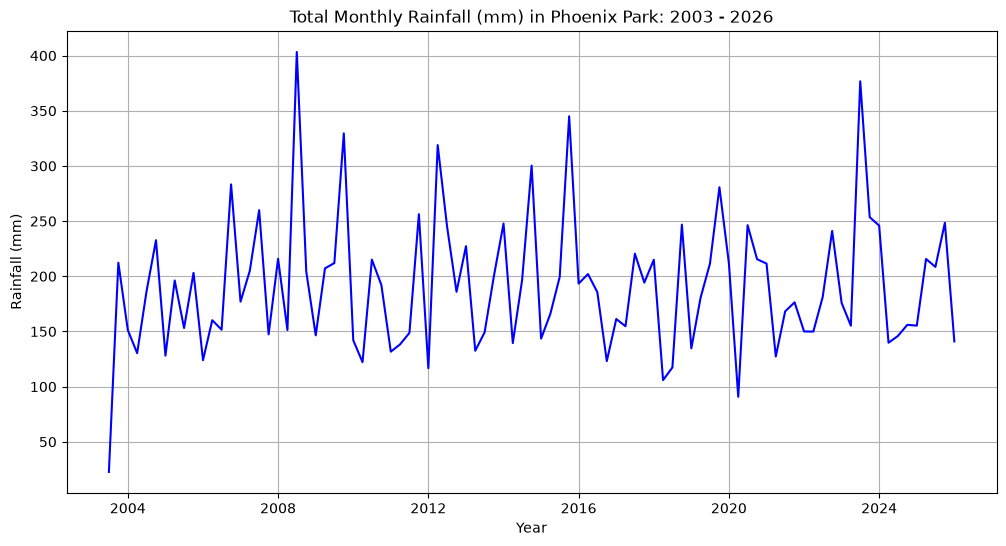

In [20]:
# Group by Year and Month (to_period('M') creates Jan-2003, Feb-2003, etc.)
rainovertime_df = weather_df.groupby(weather_df['date'].dt.to_period('Q'))['rain'].sum().reset_index()

# Convert period back to timestamp for plotting because it doesn't work with datetime here
# mainly due to it ordering itself alphabetically if not turned into a timestamp
rainovertime_df['date'] = rainovertime_df['date'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(data=rainovertime_df, x='date', y='rain', color = 'blue')


plt.title("Total Monthly Rainfall (mm) in Phoenix Park: 2003 - 2026")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.show()
